In [3]:
import csv
import numpy as np
import pandas as pd
from collections import Counter


In [6]:


def entropy(y):
    hist = np.bincount(y)
    ps = hist / len(y)
    return -np.sum([p * np.log2(p) for p in ps if p > 0])

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None

In [7]:
class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        self.n_features = X.shape[1] if not self.n_features else min(X.shape[1], self.n_features)
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)

        best_feat, best_thresh = self._best_split(X, y, feat_idxs)

        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(best_feat, best_thresh, left, right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_threshold = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            for thr in thresholds:
                gain = self._information_gain(y, X_column, thr)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = thr

        return split_idx, split_threshold

    def _information_gain(self, y, X_column, threshold):
        parent_entropy = entropy(y)

        left_idxs, right_idxs = self._split(X_column, threshold)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0
        
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = entropy(y[left_idxs]), entropy(y[right_idxs])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r

        return parent_entropy - child_entropy

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _most_common_label(self, y):
        counter = Counter(y)
        return counter.most_common(1)[0][0]

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

In [8]:
try:
    df = pd.read_csv("loan_train.csv", on_bad_lines='skip')
except FileNotFoundError:
    exit()

for col in df.columns:
    df[col] = df[col].fillna(df[col].mode()[0])

categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Area', 'Status']
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

In [9]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

total = len(df)
train_end = int(0.6 * total)
val_end   = int(0.8 * total)

X = df.drop('Status', axis=1).values
y = df['Status'].values

X_train, y_train = X[:train_end],       y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]

print(f"Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}")
clf = DecisionTree(max_depth=4)
clf.fit(X_train, y_train)

for name, Xs, ys in [("Train", X_train, y_train),
                     ("Val  ", X_val,   y_val),
                     ("Test ", X_test,  y_test)]:
    preds = clf.predict(Xs)
    acc = np.sum(preds == ys) / len(ys)
    print(f"{name} accuracy: {acc * 100:.2f}%")


Train: 368 | Val: 123 | Test: 123
Train accuracy: 83.42%
Val   accuracy: 77.24%
Test  accuracy: 78.86%


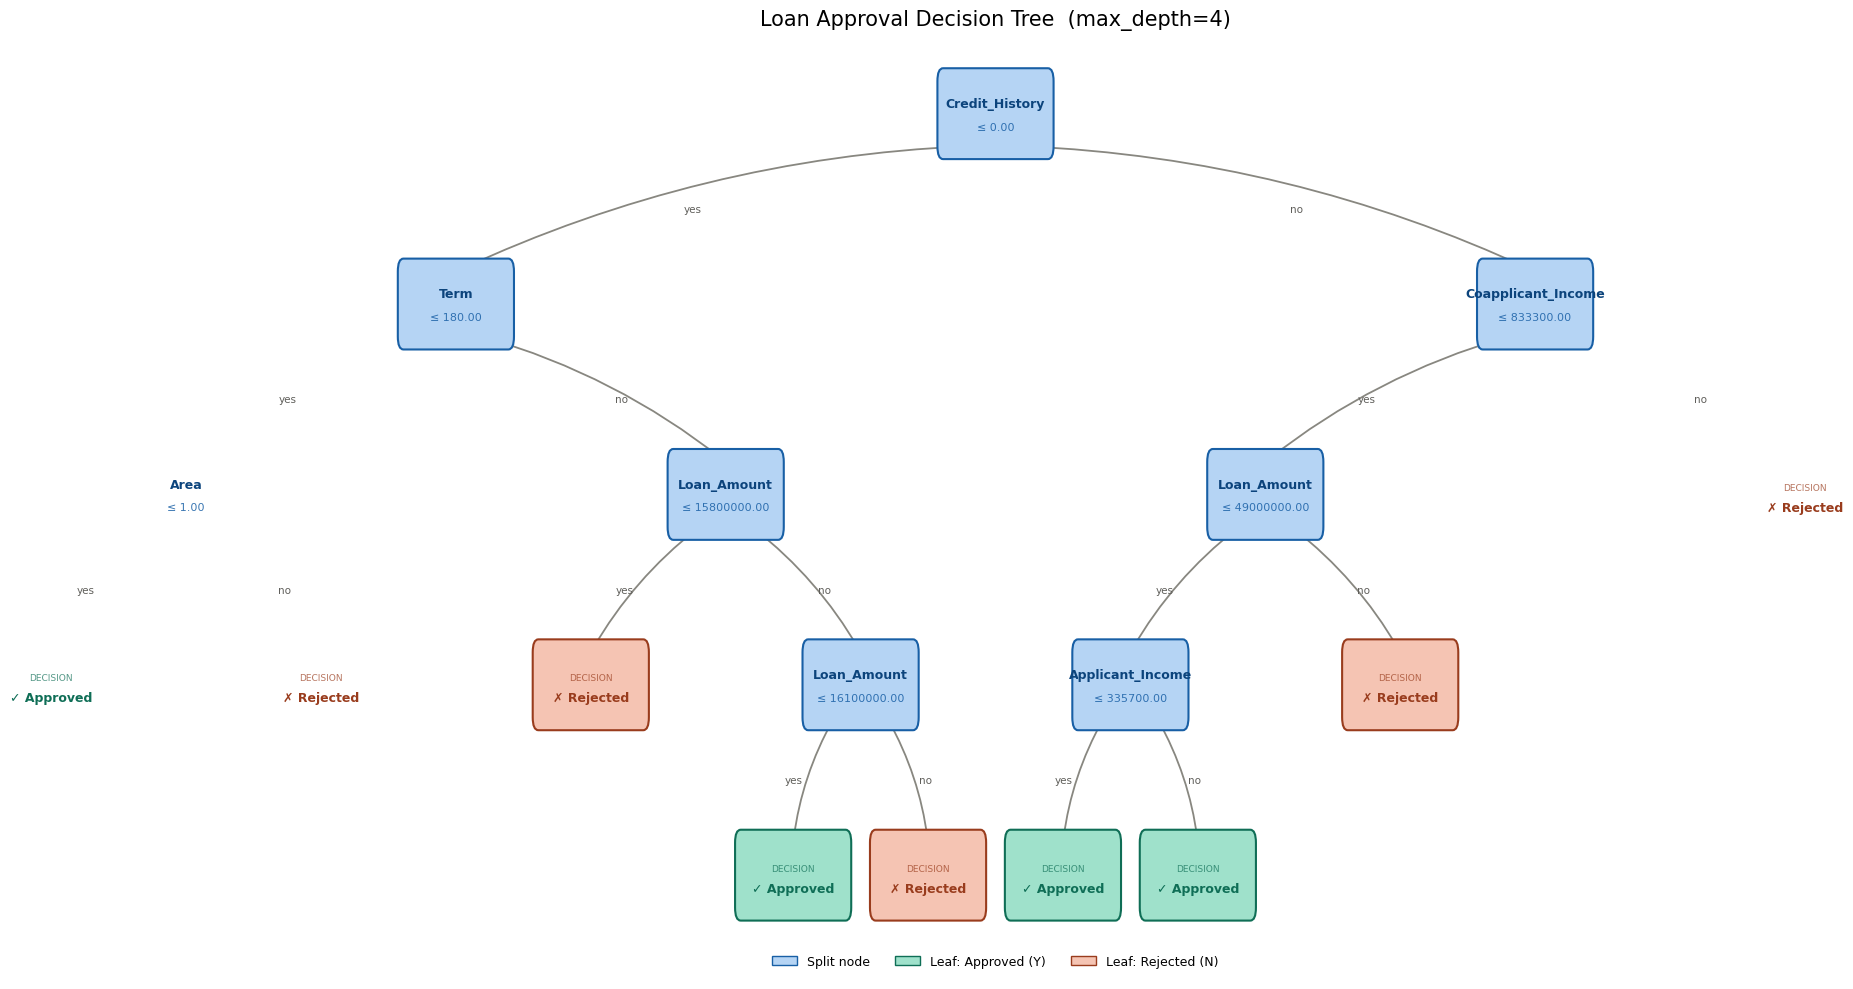

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

def plot_tree(node, ax, feature_names,
              x=0, y=0, dx=5.5, dy=2.2,
              node_w=2.8, node_h=0.75):

    if node.is_leaf_node():
        approved = node.value == 1
        color  = "#9FE1CB" if approved else "#F5C4B3"
        border = "#0F6E56" if approved else "#993C1D"
        text   = "✓ Approved" if approved else "✗ Rejected"
        box = FancyBboxPatch((x - node_w/2, y - node_h/2), node_w, node_h,
                             boxstyle="round,pad=0.15", linewidth=1.5,
                             edgecolor=border, facecolor=color, zorder=3)
        ax.add_patch(box)
        ax.text(x, y + 0.08, "DECISION", ha="center", va="center",
                fontsize=6.5, color=border, alpha=0.7, zorder=4)
        ax.text(x, y - 0.15, text, ha="center", va="center",
                fontsize=9, fontweight="bold", color=border, zorder=4)
        return

    feat_name = feature_names[node.feature]
    box = FancyBboxPatch((x - node_w/2, y - node_h/2), node_w, node_h,
                         boxstyle="round,pad=0.15", linewidth=1.5,
                         edgecolor="#185FA5", facecolor="#B5D4F4", zorder=3)
    ax.add_patch(box)
    ax.text(x, y + 0.12, feat_name, ha="center", va="center",
            fontsize=9, fontweight="bold", color="#0C447C", zorder=4)
    ax.text(x, y - 0.15, f"≤ {node.threshold:.2f}", ha="center", va="center",
            fontsize=8, color="#185FA5", alpha=0.85, zorder=4)

    lx, ly = x - dx, y - dy
    rx, ry = x + dx, y - dy
    my = (y - node_h/2 + ly + node_h/2) / 2

    ax.annotate("", xy=(lx, ly + node_h/2), xytext=(x - node_w/4, y - node_h/2),
                arrowprops=dict(arrowstyle="-|>", color="#888780",
                                connectionstyle="arc3,rad=0.1", lw=1.3), zorder=2)
    ax.text((x - node_w/4 + lx)/2 - 0.3, my, "yes",
            ha="right", va="center", fontsize=7.5, color="#5F5E5A")

    ax.annotate("", xy=(rx, ry + node_h/2), xytext=(x + node_w/4, y - node_h/2),
                arrowprops=dict(arrowstyle="-|>", color="#888780",
                                connectionstyle="arc3,rad=-0.1", lw=1.3), zorder=2)
    ax.text((x + node_w/4 + rx)/2 + 0.3, my, "no",
            ha="left", va="center", fontsize=7.5, color="#5F5E5A")

    plot_tree(node.left,  ax, feature_names, lx, ly, dx/2, dy, node_w, node_h)
    plot_tree(node.right, ax, feature_names, rx, ry, dx/2, dy, node_w, node_h)


def get_tree_depth(node):
    if node.is_leaf_node():
        return 0
    return 1 + max(get_tree_depth(node.left), get_tree_depth(node.right))


def visualize_decision_tree(clf, df):
    feature_names = list(df.drop("Status", axis=1).columns)

    depth = get_tree_depth(clf.root)

    dy      = 2.2
    dx_root = 2 ** (depth - 1) * 1.8      
    fig_w   = max(14, depth * 5)
    fig_h   = max(6,  depth * 2.5)

    x_pad  = dx_root + 2
    y_top  = 0.8
    y_bot  = -(depth * dy + 1.2)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_axis_off()
    ax.set_xlim(-x_pad, x_pad)
    ax.set_ylim(y_bot, y_top)

    plot_tree(clf.root, ax, feature_names, x=0, y=0, dx=dx_root, dy=dy)

    handles = [
        mpatches.Patch(facecolor="#B5D4F4", edgecolor="#185FA5", label="Split node"),
        mpatches.Patch(facecolor="#9FE1CB", edgecolor="#0F6E56", label="Leaf: Approved (Y)"),
        mpatches.Patch(facecolor="#F5C4B3", edgecolor="#993C1D", label="Leaf: Rejected (N)"),
    ]
    ax.legend(handles=handles, loc="lower center", ncol=3,
              frameon=False, fontsize=9, bbox_to_anchor=(0.5, 0.0))

    plt.title(f"Loan Approval Decision Tree  (max_depth={depth})",
              fontsize=15, fontweight="500", pad=14)
    plt.tight_layout()
    plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
    plt.show()


visualize_decision_tree(clf, df)